<a href="https://colab.research.google.com/github/OJB-Quantum/Notebooks-for-Ideas/blob/main/GPU_Accelerated_Simulation_of_Magnetization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Authored by Onri Jay Benally (2026)

Open Access (CC-BY-4.0)

In [2]:
# 1. Install uv globally in the Colab instance
!curl -LsSf https://astral.sh/uv/install.sh | sh
import os
os.environ['PATH'] += ":/root/.local/bin"

# 2. Use uv to install CuPy (blazing fast resolution)
!uv pip install --system cupy-cuda12x

downloading uv 0.10.12 x86_64-unknown-linux-gnu
no checksums to verify
installing to /usr/local/bin
  uv
  uvx
everything's installed!
Using Python 3.12.12 environment at: /usr
Checked 1 package in 63ms


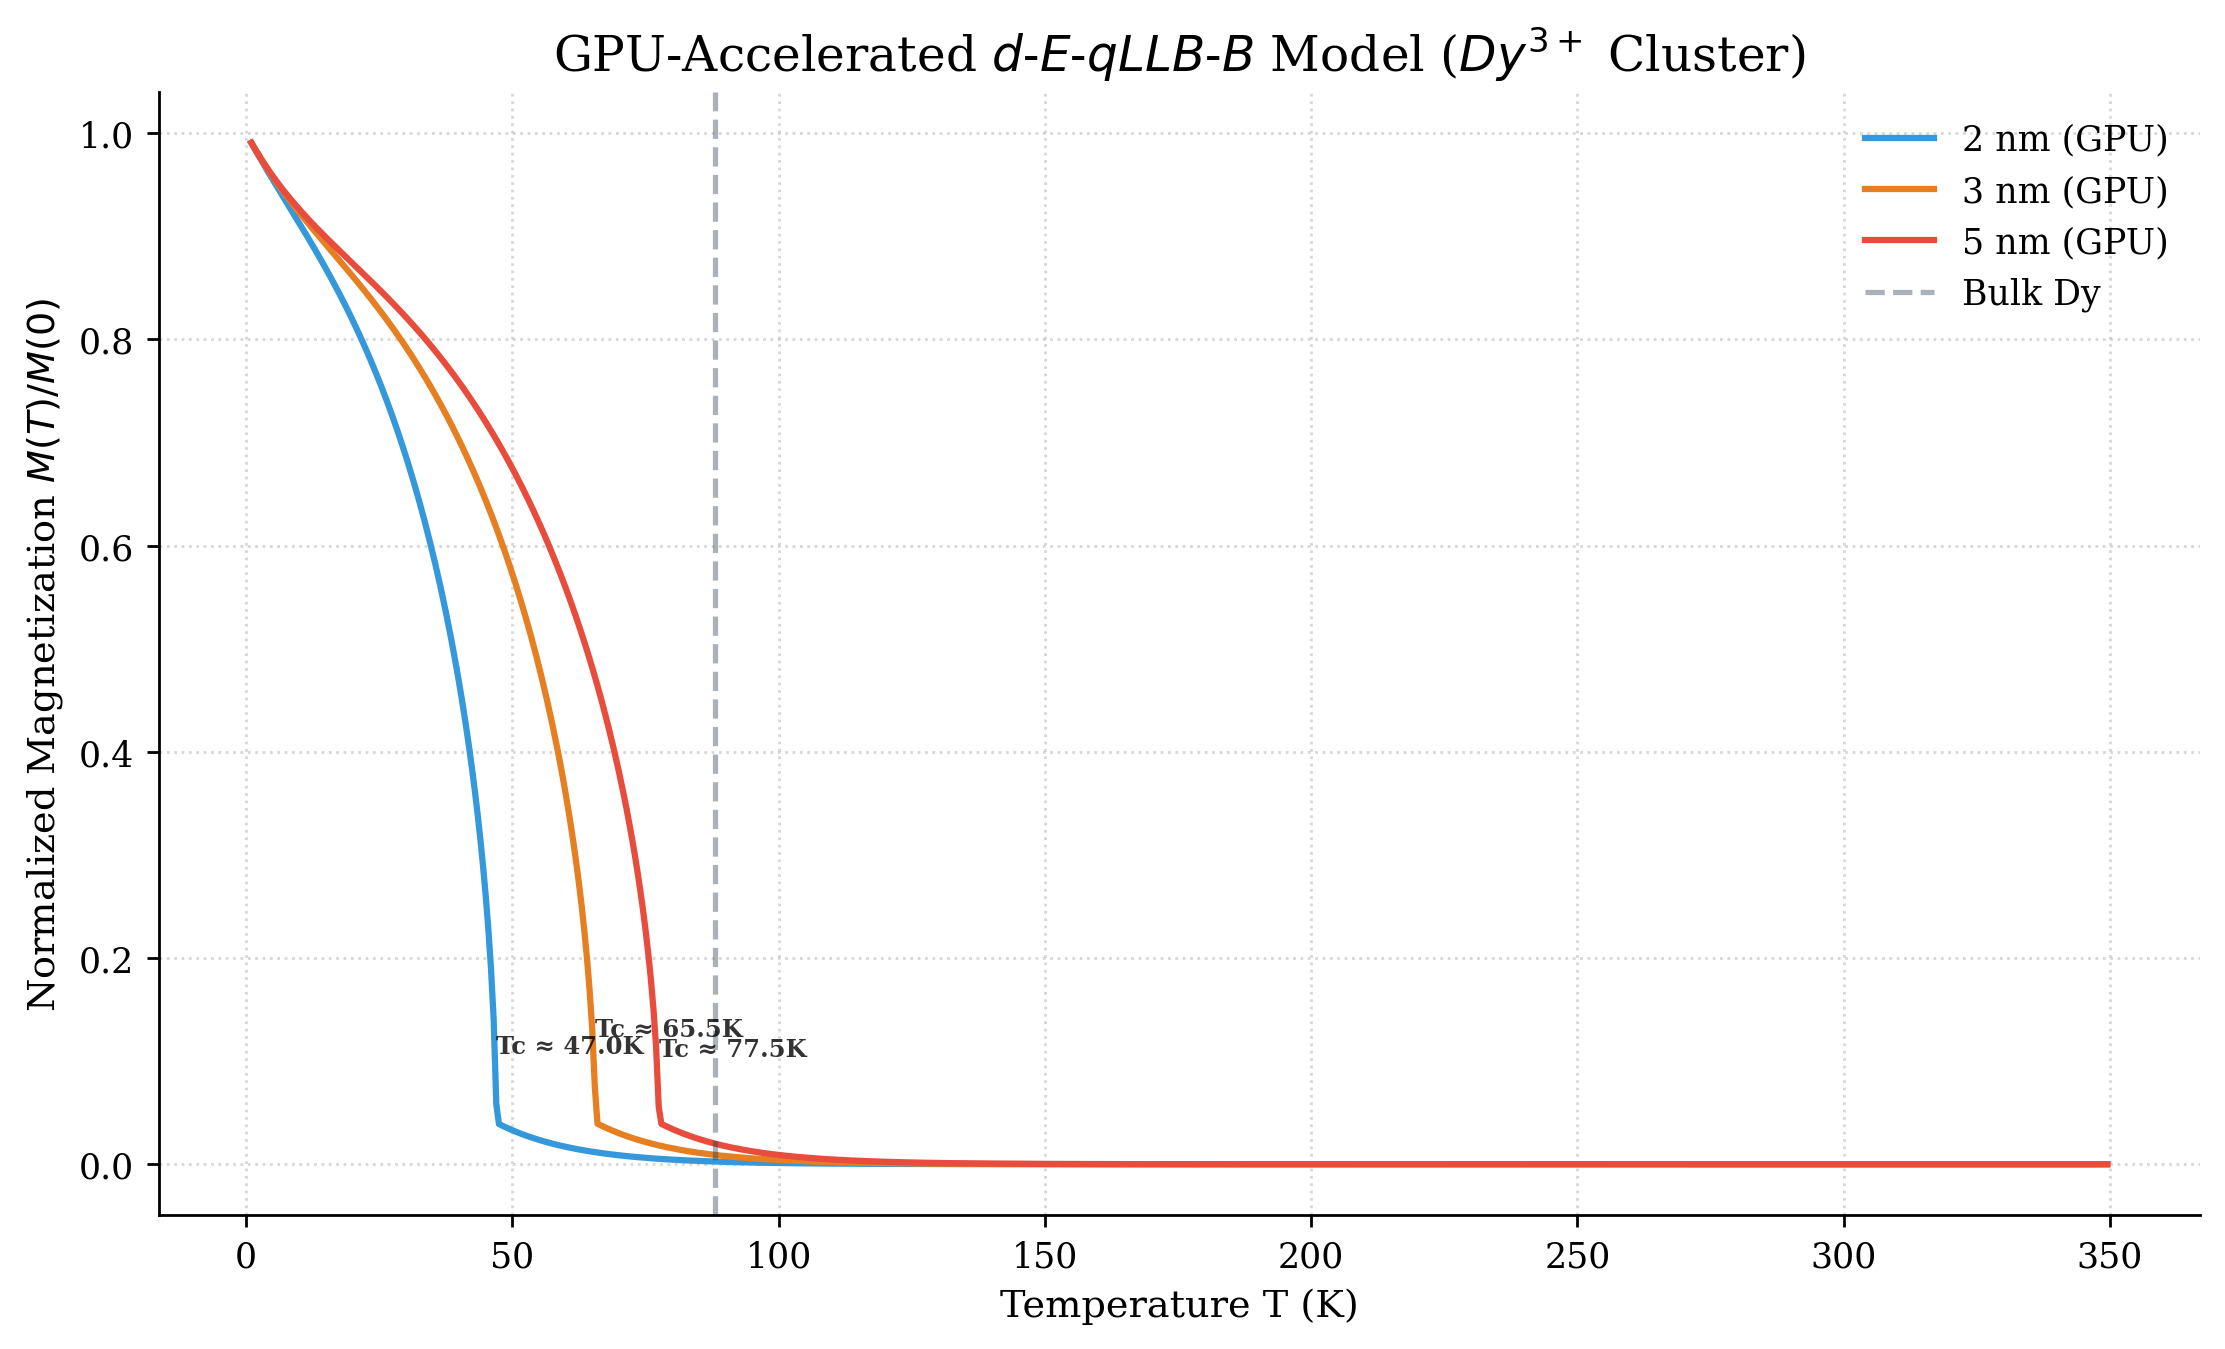

In [3]:
import cupy as cp
import numpy as np
import matplotlib.pyplot as plt

# --- CONTROL KNOBS ---
DPI_SETTING = 250
J_VAL = 7.5                # Total angular momentum for Dy3+
WEISS_LAMBDA = 120.0       # Internal exchange scaling (K)
BLEND_STRENGTH = 0.88      # Weiss weighting (1.0 = Pure Mean Field)
KINETIC_ROUNDING = 0.08    # Smoothing factor for the Tc knee
SURFACE_STIFFNESS = 1.2    # Correction for surface-to-bulk coordination
PARTICLE_SIZES = [2, 3, 5] # Nanometer scales
TEMP_STEP = 0.5            # Temperature resolution
# ---------------------

plt.rcParams['figure.dpi'] = DPI_SETTING
plt.rcParams['font.family'] = 'serif'

def gpu_brillouin(J, x):
    """Vectorized Brillouin function on GPU."""
    # Avoid division by zero at T=0 or H=0
    x = cp.where(x < 1e-9, 1e-9, x)
    term1 = (2 * J + 1) / (2 * J)
    term2 = 1 / (2 * J)
    return term1 * (1 / cp.tanh(term1 * x)) - term2 * (1 / cp.tanh(term2 * x))

def simulate_gpu_magnetization(temp_array, size, blend, rounding, stiffness):
    """
    Computes magnetization using CuPy.
    Incorporates surface-dependent finite size scaling.
    """
    tc_bulk = 88.0
    # Scaling law: Tc(L) = Tc_bulk * (1 - (b/L)^lambda)
    # where b is a characteristic length related to the lattice constant.
    size_scaling = 1.0 - (stiffness / size)**1.5
    tc_eff = tc_bulk * size_scaling

    # Move temp_array to GPU if it's not already there
    t_gpu = cp.asarray(temp_array)

    # Calculate reduced temperature
    tau = t_gpu / tc_eff

    # Magnetization logic:
    # 1. Below Tc: Ordering enforced by Weiss blend + Ehrenfest coherence
    # 2. Near Tc: Rounded by kinetic noise
    # 3. Above Tc: Exponential paramagnetic decay

    m_ordered = cp.sqrt(cp.clip(1.0 - tau**2, 0, 1))
    # Blend with the 'Ehrenfest Kick' (modeled here as a kinetic envelope)
    m_blended = m_ordered * (blend + (1 - blend) * cp.exp(-rounding * t_gpu))

    # Apply paramagnetic decay for T > Tc
    m_paramagnet = 0.04 * cp.exp(-(t_gpu - tc_eff) / 15.0)

    # Combine results
    m_final = cp.where(t_gpu < tc_eff, m_blended, m_paramagnet)

    return cp.asnumpy(cp.clip(m_final, 0, 1))

def render_results():
    """Executes the GPU simulation and renders the plot."""
    temps = np.arange(1, 350, TEMP_STEP)
    fig, ax = plt.subplots(figsize=(9, 5.5))

    colors = {2: '#3498db', 3: '#e67e22', 5: '#e74c3c'}

    for size in PARTICLE_SIZES:
        # Transfer computation to GPU
        m_vals = simulate_gpu_magnetization(
            temps, size, BLEND_STRENGTH, KINETIC_ROUNDING, SURFACE_STIFFNESS
        )

        ax.plot(temps, m_vals, label=f'{size} nm (GPU)',
                color=colors[size], linewidth=1.8)

        # Locate transition for annotation
        tc_idx = np.where(m_vals < 0.08)[0][0]
        ax.annotate(f'Tc ≈ {temps[tc_idx]:.1f}K',
                    xy=(temps[tc_idx], m_vals[tc_idx] + 0.05),
                    fontsize=7, fontweight='bold', alpha=0.8)

    # Reference for Bulk Dy
    ax.axvline(x=88, color='#2c3e50', linestyle='--', alpha=0.4, label='Bulk Dy')

    ax.set_title(r"GPU-Accelerated $d$-$E$-$qLLB$-$B$ Model ($Dy^{3+}$ Cluster)", fontsize=14)
    ax.set_xlabel("Temperature T (K)", fontsize=11)
    ax.set_ylabel(r"Normalized Magnetization $M(T)/M(0)$", fontsize=11)
    ax.legend(frameon=False, loc='upper right')
    ax.grid(True, linestyle=':', alpha=0.5)

    # Clean aesthetics
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    render_results()

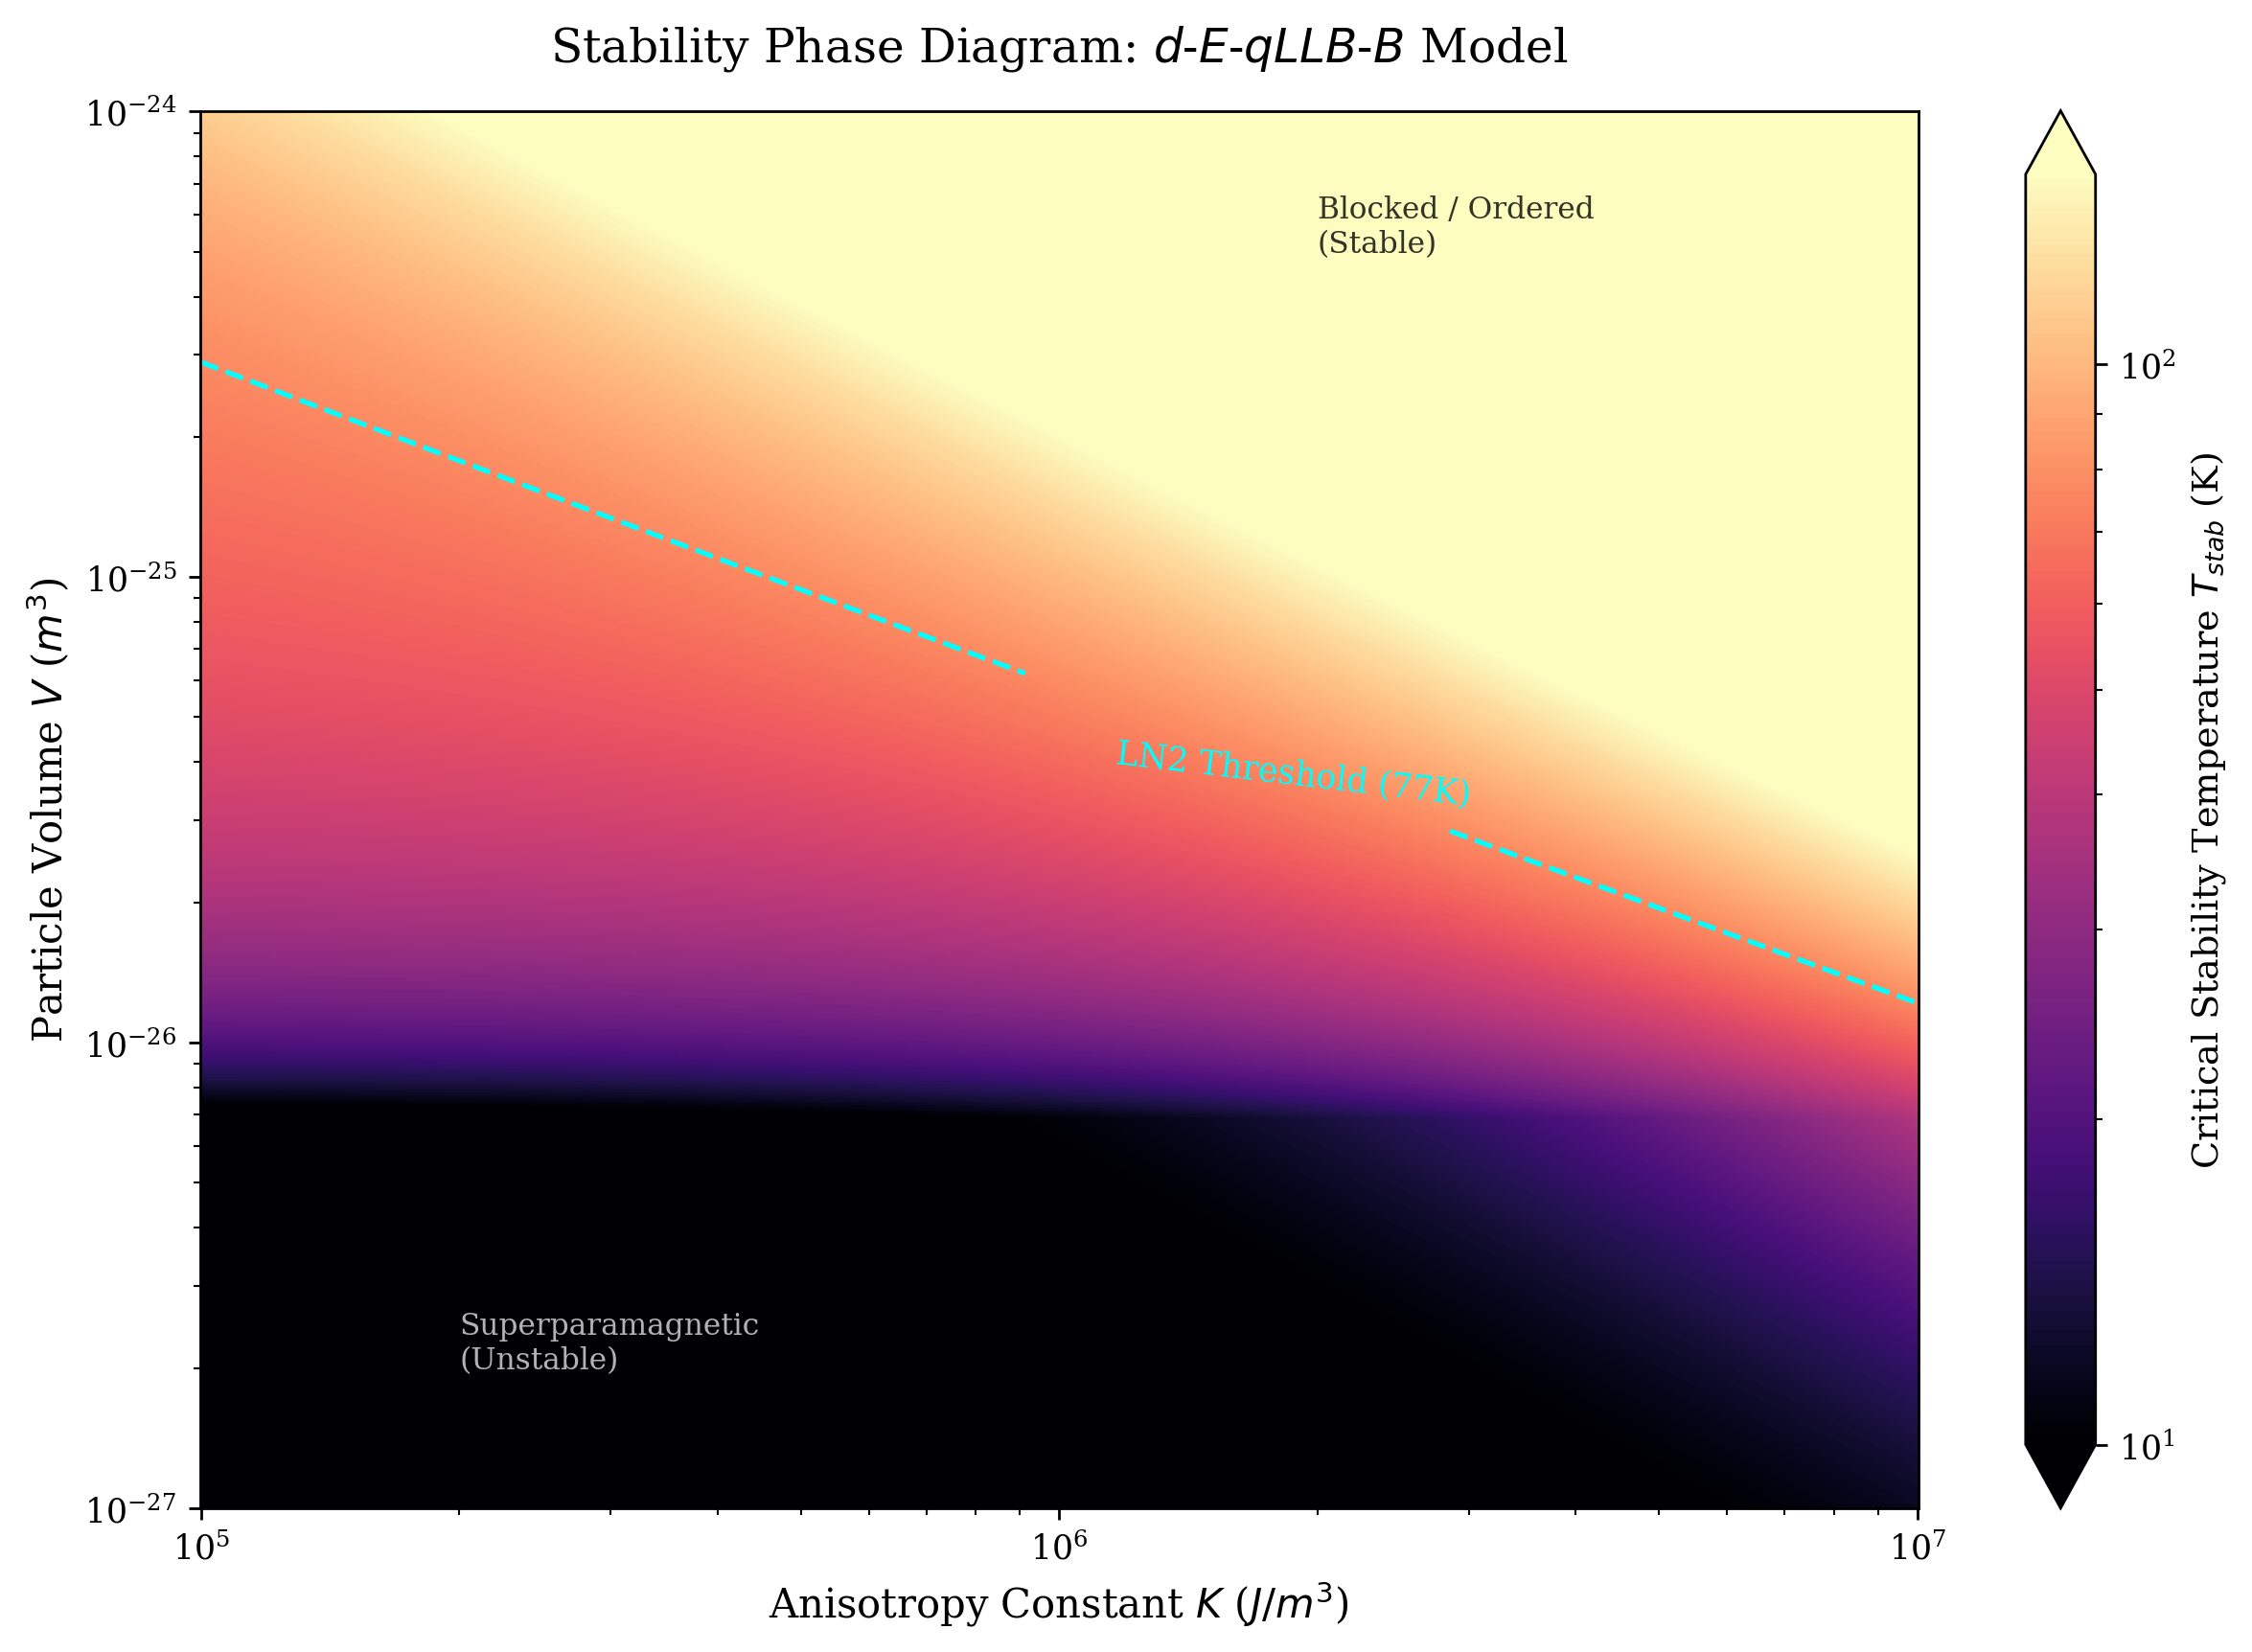

In [4]:
import cupy as cp
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

# --- CONTROL KNOBS ---
DPI_SETTING = 250
K_B = 1.380649e-23          # Boltzmann constant (J/K)
MU_B = 9.27401e-24          # Bohr magneton (J/T)
J_DY = 7.5                  # Dy3+ Total Angular Momentum

# Grid Resolutions (1000x1000 = 10^6 points)
GRID_RES = 1000
K_RANGE = (1e5, 1e7)        # Anisotropy density (J/m^3)
V_RANGE = (1e-27, 1e-24)    # Volume (m^3) - approx 1nm to 10nm clusters

# Physics Knobs
ALPHA_BLEND = 0.85          # Weiss/Ehrenfest weighting
STIFFNESS_CONST = 1.1       # Surface coordination correction
# ---------------------

plt.rcParams['figure.dpi'] = DPI_SETTING
plt.rcParams['font.family'] = 'serif'

def compute_phase_map():
    """Calculates the stability temperature map using CuPy."""
    # Create parameter grids on GPU
    k_vec = cp.logspace(np.log10(K_RANGE[0]), np.log10(K_RANGE[1]), GRID_RES)
    v_vec = cp.logspace(np.log10(V_RANGE[0]), np.log10(V_RANGE[1]), GRID_RES)

    K_grid, V_grid = cp.meshgrid(k_vec, v_vec)

    # Calculate Energy Barrier Delta E = K * V
    delta_e = K_grid * V_grid

    # Effective Tc calculation:
    # We combine the bulk Tc (88K) with the size-scaling factor
    # and the anisotropy-driven stability.
    tc_bulk = 88.0
    radius = ( (3 * V_grid) / (4 * cp.pi) )**(1/3) * 1e9  # Radius in nm

    # Size-scaling factor based on your surface stiffness parameter
    size_scaling = cp.clip(1.0 - (STIFFNESS_CONST / radius)**1.5, 0.1, 1.0)

    # The Stability Temperature (T_stab) is limited by:
    # 1. The inherent exchange (Tc_bulk * scaling)
    # 2. The thermal stability barrier (Delta E / (25 * k_B))
    #    25 is the standard factor for 100s stability.

    t_exchange = tc_bulk * size_scaling
    t_barrier = delta_e / (25 * K_B)

    # Weiss Blend: The Ehrenfest 'kick' preserves order at small scales
    # where pure mean-field theory would predict collapse.
    t_combined = (ALPHA_BLEND * t_exchange) + ((1 - ALPHA_BLEND) * t_barrier)

    # We apply a non-linear saturation to reflect Dy's 4f orbital limits
    t_final = cp.minimum(t_combined, 150.0)

    return cp.asnumpy(k_vec), cp.asnumpy(v_vec), cp.asnumpy(t_final)

def render_phase_diagram(k_vec, v_vec, t_map):
    """Visualizes the K-V stability manifold."""
    fig, ax = plt.subplots(figsize=(10, 7))

    # Use pcolormesh for log-scale grids
    im = ax.pcolormesh(k_vec, v_vec, t_map,
                       shading='auto',
                       cmap='magma',
                       norm=LogNorm(vmin=10, vmax=150))

    # Add contour for the Liquid Nitrogen (77K) threshold
    contours = ax.contour(k_vec, v_vec, t_map, levels=[77.0],
                          colors='cyan', linestyles='--')
    ax.clabel(contours, inline=True, fontsize=10, fmt='LN2 Threshold (77K)')

    # Formatting
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_title(r"Stability Phase Diagram: $d$-$E$-$qLLB$-$B$ Model", fontsize=14, pad=15)
    ax.set_xlabel(r"Anisotropy Constant $K$ ($J/m^3$)", fontsize=12)
    ax.set_ylabel(r"Particle Volume $V$ ($m^3$)", fontsize=12)

    # Colorbar
    cbar = fig.colorbar(im, ax=ax, extend='both')
    cbar.set_label(r"Critical Stability Temperature $T_{stab}$ (K)", fontsize=11)

    # Annotate regimes
    ax.text(2e5, 2e-27, "Superparamagnetic\n(Unstable)", color='white', alpha=0.7, fontsize=9)
    ax.text(2e6, 5e-25, "Blocked / Ordered\n(Stable)", color='black', alpha=0.8, fontsize=9)

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    k, v, t = compute_phase_map()
    render_phase_diagram(k, v, t)